# Test-M G-PCCA Recomputation

Recomputes G-PCCA at a user-specified **`M_TEST`** using the saved cluster-assignment
state files (states directory).

**What changes with M:**
- `chi_global_aligned` and `chi_macro_aligned` (new M columns)
- `arm_assignments_global_aligned` and `arm_assignments_macro_aligned`

**What does NOT change with M (copied from existing saved arrays):**
- Transfer-operator eigenvectors / eigenspace coordinates (`phi_*`)
- Cluster occupancy (`occupancy_global`, `macro_occupancy`)
- Stationary distribution (`pi_macro`)
- Eigenvalues (`evals`)

**Outputs saved to:**
```
XY_EvenSampled_SlowModes/test_M/{species}/
```


## 1. Parameters and Paths

In [40]:
# ── USER: set your desired number of basins ──────────────────────────────────
M_TEST = 2   # ← change this

# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import shutil
import warnings
warnings.filterwarnings("ignore")

RUN_ROOT = Path(
    "/Users/meganbishop/slowmodeevo/outputs/"
    "multispecies_slow_modes/global_clustering_modes/"
    "global_outputs/XY_EvenSampled_SlowModes"
)
EXPORT_ROOT  = RUN_ROOT / "saved_slow_mode_arrays"
TEST_M_ROOT  = RUN_ROOT / "test_M"
STATES_DIR   = RUN_ROOT / "states"
ORIG_VIEW    = "with_low_occupancy_cutoff"

TAU_FRAMES   = 120          # 1 s at 120 Hz
N_CLUSTERS   = 1000
PSEUDOCOUNT  = 1e-6

ALL_SPECIES = [
    "Mus_caroli", "Mus_musculus", "Mus_spretus",
    "Peromyscus_californicus", "Peromyscus_gossypinus",
    "Peromyscus_leucopus", "Peromyscus_maniculatus", "Peromyscus_polionotus",
]

TEST_M_ROOT.mkdir(exist_ok=True)
print(f"M_TEST      = {M_TEST}")
print(f"Output root = {TEST_M_ROOT}")
print(f"States dir  = {STATES_DIR}  (exists: {STATES_DIR.exists()})")
print(f"Orig arrays = {EXPORT_ROOT / ORIG_VIEW}  (exists: {(EXPORT_ROOT / ORIG_VIEW).exists()})")


M_TEST      = 2
Output root = /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/test_M
States dir  = /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/states  (exists: True)
Orig arrays = /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/saved_slow_mode_arrays/with_low_occupancy_cutoff  (exists: True)


## 2. Helper Functions

In [41]:
try:
    from pygpcca import GPCCA
    HAS_GPCCA = True
except ImportError:
    HAS_GPCCA = False
    print("pygpcca not found — install with:  pip install pygpcca")

from scipy.sparse.linalg import eigs
from scipy.optimize import linear_sum_assignment


def build_T(species, tau=TAU_FRAMES, pc=PSEUDOCOUNT):
    """Build 1000x1000 row-stochastic transition matrix from all states files."""
    files = sorted(STATES_DIR.glob(f"{species}__subject__*_states.npy"))
    if not files:
        raise FileNotFoundError(f"No states files for {species}")
    counts = np.zeros((N_CLUSTERS, N_CLUSTERS), dtype=np.float64)
    for f in files:
        seq = np.load(f).astype(int)
        src, dst = seq[:-tau], seq[tau:]
        np.add.at(counts, (src, dst), 1)
    counts += pc
    return counts / counts.sum(axis=1, keepdims=True)


def stationary_dist(T):
    vals, vecs = eigs(T.T, k=1, which='LM')
    pi = np.abs(vecs[:, 0].real)
    pi = np.maximum(pi, 1e-12)
    return pi / pi.sum()


def run_gpcca(T, pi, M):
    """Run G-PCCA and return chi (N x M).  Retries at M+1 on complex-conjugate error."""
    if not HAS_GPCCA:
        raise RuntimeError("pygpcca required")
    eta = np.maximum(pi, 1e-12); eta /= eta.sum()
    g = GPCCA(T, eta=eta, z='LM', method='brandts')
    try:
        g.optimize(M)
    except ValueError as exc:
        if 'complex conjugate' in str(exc).lower():
            g = GPCCA(T, eta=eta, z='LM', method='brandts')
            g.optimize(M + 1)
            chi  = g.memberships
            mass = chi.T @ eta
            keep = np.argsort(-mass)[:M]
            chi  = chi[:, keep]
            chi /= chi.sum(axis=1, keepdims=True)
            return chi
        raise
    return g.memberships   # (N, M)


def hungarian_align(chi_ref, chi_new):
    """Permute columns of chi_new to best match chi_ref by cosine similarity."""
    ref_n = chi_ref / (np.linalg.norm(chi_ref, axis=0, keepdims=True) + 1e-12)
    new_n = chi_new / (np.linalg.norm(chi_new, axis=0, keepdims=True) + 1e-12)
    cost  = -(ref_n.T @ new_n)
    row_ind, col_ind = linear_sum_assignment(cost)
    return chi_new[:, col_ind], col_ind


## 3. Recompute G-PCCA at M_TEST

In [42]:
chi_globals   = {}   # species -> (1000, M_TEST)  unaligned
chi_macros    = {}   # species -> (N_retained, M_TEST)  unaligned
macro_indices = {}   # species -> 1-D array of global cluster indices in macro set

for species in ALL_SPECIES:
    print(f"\n=== {species} ===")
    orig_dir  = EXPORT_ROOT / ORIG_VIEW / species

    # ── Identify macro cluster indices ───────────────────────────────────────
    # Use the saved phi_macro_native shape to learn exactly how many macro
    # clusters notebook 00 kept (avoids re-implementing the exact cutoff).
    occ_global = np.load(orig_dir / "occupancy_global.npy")   # (1000,)
    N_retained = int(np.load(orig_dir / "phi_macro_native.npy").shape[0])
    # Top-N by occupancy, sorted ascending so matrix indexing is contiguous
    macro_idx  = np.sort(np.argsort(-occ_global)[:N_retained])
    macro_indices[species] = macro_idx
    print(f"  Macro clusters: {N_retained} / {N_CLUSTERS}")

    # ── Build transition matrix ──────────────────────────────────────────────
    print(f"  Building T …", end="", flush=True)
    T_full  = build_T(species)
    pi_full = stationary_dist(T_full)
    print(" done")

    # ── Global G-PCCA (all 1000 clusters) ────────────────────────────────────
    print(f"  G-PCCA global  M={M_TEST} …", end="", flush=True)
    chi_global = run_gpcca(T_full, pi_full, M_TEST)   # (1000, M_TEST)
    print(" done")

    # ── Macro submatrix G-PCCA ────────────────────────────────────────────────
    print(f"  G-PCCA macro   M={M_TEST} …", end="", flush=True)
    T_macro  = T_full[np.ix_(macro_idx, macro_idx)]
    T_macro  = T_macro / T_macro.sum(axis=1, keepdims=True)
    pi_macro = stationary_dist(T_macro)
    chi_macro = run_gpcca(T_macro, pi_macro, M_TEST)   # (N_retained, M_TEST)
    print(" done")

    chi_globals[species]  = chi_global
    chi_macros[species]   = chi_macro

print("\n✓ All species computed.")



=== Mus_caroli ===
  Macro clusters: 625 / 1000
  Building T … done
  G-PCCA global  M=2 … done
  G-PCCA macro   M=2 … done

=== Mus_musculus ===
  Macro clusters: 875 / 1000
  Building T … done
  G-PCCA global  M=2 … done
  G-PCCA macro   M=2 … done

=== Mus_spretus ===
  Macro clusters: 425 / 1000
  Building T … done
  G-PCCA global  M=2 … done
  G-PCCA macro   M=2 … done

=== Peromyscus_californicus ===
  Macro clusters: 925 / 1000
  Building T … done
  G-PCCA global  M=2 … done
  G-PCCA macro   M=2 … done

=== Peromyscus_gossypinus ===
  Macro clusters: 975 / 1000
  Building T … done
  G-PCCA global  M=2 … done
  G-PCCA macro   M=2 … done

=== Peromyscus_leucopus ===
  Macro clusters: 325 / 1000
  Building T … done
  G-PCCA global  M=2 … done
  G-PCCA macro   M=2 … done

=== Peromyscus_maniculatus ===
  Macro clusters: 925 / 1000
  Building T … done
  G-PCCA global  M=2 … done
  G-PCCA macro   M=2 … done

=== Peromyscus_polionotus ===
  Macro clusters: 675 / 1000
  Building T … do

## 4. Cross-Species Arm Alignment

In [43]:
# Align every species to the first species as a cosine-similarity reference.
# The same column permutation is applied to both chi_global and chi_macro.

ref_species = ALL_SPECIES[0]
ref_chi_g   = chi_globals[ref_species]

chi_globals_aligned = {}
chi_macros_aligned  = {}
chi_globals_aligned[ref_species] = ref_chi_g
chi_macros_aligned[ref_species]  = chi_macros[ref_species]

for species in ALL_SPECIES[1:]:
    chi_g_aligned, col_order = hungarian_align(ref_chi_g, chi_globals[species])
    chi_m_aligned             = chi_macros[species][:, col_order]
    chi_globals_aligned[species] = chi_g_aligned
    chi_macros_aligned[species]  = chi_m_aligned
    print(f"  {species}: arm order → {col_order}")

print("\n✓ Alignment done.  Reference species:", ref_species)


  Mus_musculus: arm order → [0 1]
  Mus_spretus: arm order → [0 1]
  Peromyscus_californicus: arm order → [0 1]
  Peromyscus_gossypinus: arm order → [0 1]
  Peromyscus_leucopus: arm order → [0 1]
  Peromyscus_maniculatus: arm order → [0 1]
  Peromyscus_polionotus: arm order → [0 1]

✓ Alignment done.  Reference species: Mus_caroli


## 5. Save Arrays to test_M/

In [44]:
# M-DEPENDENT: recomputed and saved fresh
NEW_ARRAYS = [
    ("chi_global_aligned.npy",             lambda sp: chi_globals_aligned[sp]),
    ("chi_macro_aligned.npy",              lambda sp: chi_macros_aligned[sp]),
    ("arm_assignments_global_aligned.npy", lambda sp: chi_globals_aligned[sp].argmax(axis=1).astype(int)),
    ("arm_assignments_macro_aligned.npy",  lambda sp: chi_macros_aligned[sp].argmax(axis=1).astype(int)),
]

# M-INDEPENDENT: copy from existing saved_slow_mode_arrays (with_low_occupancy_cutoff)
COPY_ARRAYS = [
    "phi_macro_native.npy",
    "phi_macro_shared.npy",
    "phi_global_shared.npy",
    "macro_occupancy.npy",
    "occupancy_global.npy",
    "pi_macro.npy",
    "evals.npy",
]

for species in ALL_SPECIES:
    out_dir  = TEST_M_ROOT / species
    out_dir.mkdir(exist_ok=True)
    orig_dir = EXPORT_ROOT / ORIG_VIEW / species

    for fname, getter in NEW_ARRAYS:
        np.save(out_dir / fname, getter(species))

    for fname in COPY_ARRAYS:
        src = orig_dir / fname
        dst = out_dir / fname
        if src.exists():
            shutil.copy2(src, dst)
        else:
            print(f"  [warn] {fname} not found in original arrays for {species}")

    chi_g = chi_globals_aligned[species]
    chi_m = chi_macros_aligned[species]
    print(f"  {species}: chi_global {chi_g.shape}  chi_macro {chi_m.shape}")

print(f"\n✓ Saved to: {TEST_M_ROOT}")


  Mus_caroli: chi_global (1000, 2)  chi_macro (625, 2)
  Mus_musculus: chi_global (1000, 2)  chi_macro (875, 2)
  Mus_spretus: chi_global (1000, 2)  chi_macro (425, 2)
  Peromyscus_californicus: chi_global (1000, 2)  chi_macro (925, 2)
  Peromyscus_gossypinus: chi_global (1000, 2)  chi_macro (975, 2)
  Peromyscus_leucopus: chi_global (1000, 2)  chi_macro (325, 2)
  Peromyscus_maniculatus: chi_global (1000, 2)  chi_macro (925, 2)
  Peromyscus_polionotus: chi_global (1000, 2)  chi_macro (675, 2)

✓ Saved to: /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/test_M


## 6. Load Arrays and Reproduce Plots

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
import pandas as pd
from scipy.ndimage import gaussian_filter
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage
from scipy.spatial.distance import squareform

N_BASINS       = M_TEST
DENSITY_BINS   = 90
DENSITY_SIGMA  = 1.25
DENSITY_VMAX_P = 99.5
ENRICH_VMAX    = 2.5
EPS            = 1e-10

species_names  = ALL_SPECIES
species_cmap   = plt.get_cmap("tab10")
species_colors = {sp: species_cmap(i / max(len(species_names)-1, 1))
                  for i, sp in enumerate(species_names)}
arm_cmap       = plt.get_cmap("Set2")
arm_colors     = [arm_cmap(i / max(N_BASINS-1, 1)) for i in range(N_BASINS)]


def load_test_M():
    result = {}
    for sp in ALL_SPECIES:
        d = {}
        for f in (TEST_M_ROOT / sp).glob("*.npy"):
            d[f.stem] = np.load(f, allow_pickle=False)
        result[sp] = d
    return result


arrs = load_test_M()
print(f"Loaded arrays for {len(arrs)} species  (M_TEST={M_TEST})")
print("Keys:", sorted(next(iter(arrs.values())).keys()))

# Optional UMAP embedding
embedding_csv = RUN_ROOT / "global_cluster_embedding.csv"
cluster_layout_2d = None
if embedding_csv.exists():
    emb = pd.read_csv(embedding_csv)
    print(f"  CSV columns: {list(emb.columns)}")
    x_cols = [c for c in emb.columns if c.lower() in ("x", "umap1", "umap_1", "umap 1", "dim1", "dim_1", "0")]
    y_cols = [c for c in emb.columns if c.lower() in ("y", "umap2", "umap_2", "umap 2", "dim2", "dim_2", "1")]
    if x_cols and y_cols:
        xy_cols = [x_cols[0], y_cols[0]]
    elif len(emb.columns) >= 2:
        xy_cols = [emb.columns[0], emb.columns[1]]
        print(f"  Falling back to first two columns: {xy_cols}")
    else:
        xy_cols = None
    if xy_cols:
        cluster_layout_2d = emb[xy_cols].values
        print(f"UMAP embedding loaded: {cluster_layout_2d.shape}  columns={xy_cols}")
    else:
        print("Could not identify 2 UMAP columns — UMAP panels will be skipped.")
else:
    print("global_cluster_embedding.csv not found — UMAP panels will be skipped.")


Loaded arrays for 8 species  (M_TEST=2)
Keys: ['arm_assignments_global_aligned', 'arm_assignments_global_aligned_3', 'arm_assignments_macro_aligned', 'arm_assignments_macro_aligned_3', 'chi_global_aligned', 'chi_global_aligned_3', 'chi_macro_aligned', 'chi_macro_aligned_3', 'evals', 'macro_occupancy', 'occupancy_global', 'phi_global_shared', 'phi_macro_native', 'phi_macro_shared', 'pi_macro']
  CSV columns: ['cluster', 'x', 'y', 'embedding_method']
UMAP embedding loaded: (1000, 2)  columns=['x', 'y']


In [46]:
def normalise_rows(X):
    X = np.asarray(X, dtype=float)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms

def arm_centroid_in_space(phi, chi, pi):
    phi, chi, pi = np.asarray(phi, float), np.asarray(chi, float), np.asarray(pi, float)
    pi = pi / max(pi.sum(), 1e-12)
    ctrs = np.zeros((chi.shape[1], phi.shape[1]))
    for arm in range(chi.shape[1]):
        w = chi[:, arm] * pi
        ctrs[arm] = (phi * w[:, None]).sum(0) / max(w.sum(), 1e-12)
    return ctrs

def grid_lims(arrays, n_dims=2):
    """Compute shared axis limits across a list of arrays."""
    pts = np.vstack([a[:, :n_dims] for a in arrays if a is not None and a.shape[1] >= n_dims])
    pts = pts[np.isfinite(pts).all(1)]
    lo, hi = pts.min(0), pts.max(0)
    pad = 0.06 * np.maximum(hi - lo, 1e-12)
    return [(lo[d]-pad[d], hi[d]+pad[d]) for d in range(n_dims)]

n_sp   = len(species_names)
n_cols = min(4, n_sp)
n_rows = int(np.ceil(n_sp / n_cols))


### 6a. Eigenvalue Spectra

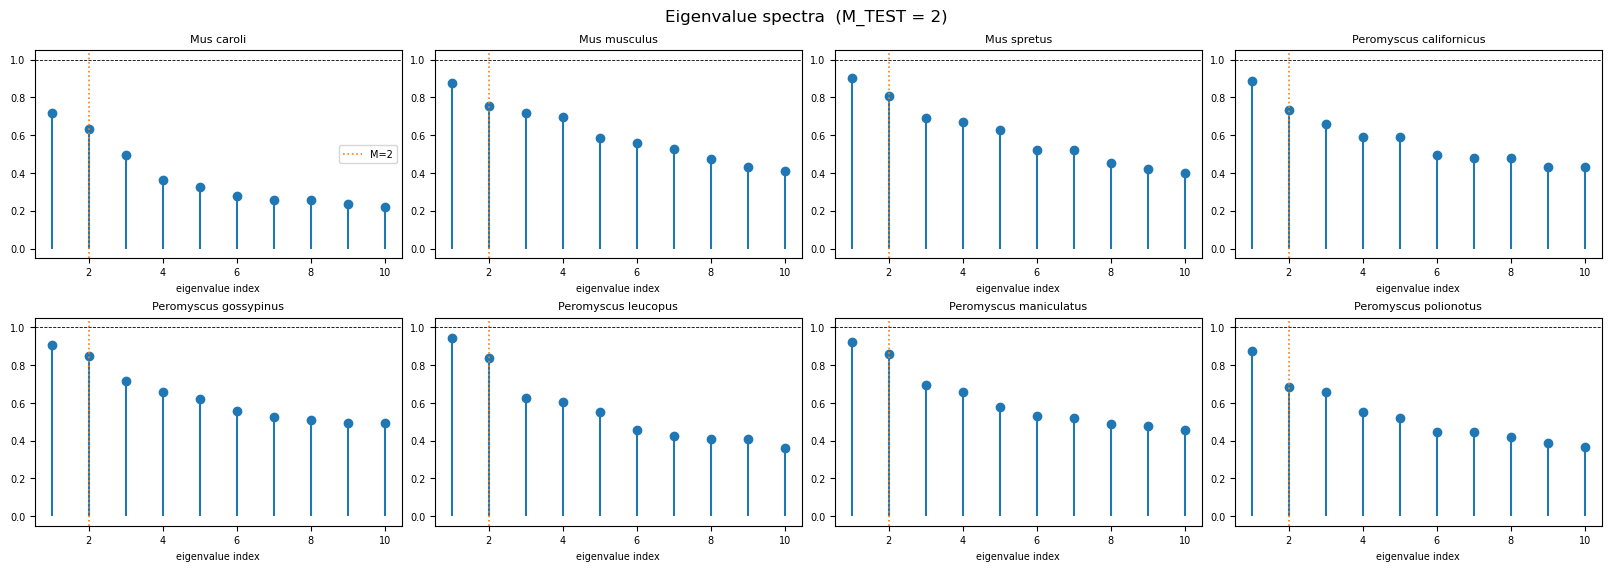

In [47]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 2.8*n_rows),
                          constrained_layout=True, squeeze=False)
for ax, sp in zip(axes.flat, species_names):
    ev = np.abs(arrs[sp].get("evals", np.array([])))
    if ev.size == 0:
        ax.set_title(f"{sp.replace('_',' ')}\nno evals"); continue
    ax.stem(np.arange(1, len(ev)+1), ev, basefmt=" ")
    ax.axhline(1.0, color="k", lw=0.6, ls="--")
    ax.axvline(M_TEST, color="tab:orange", lw=1.2, ls=":", label=f"M={M_TEST}")
    ax.set_title(sp.replace("_"," "), fontsize=8)
    ax.set_xlabel("eigenvalue index", fontsize=7)
    ax.tick_params(labelsize=7)
    if ax is axes.flat[0]:
        ax.legend(fontsize=7)
for ax in axes.flat[n_sp:]:
    ax.remove()
fig.suptitle(f"Eigenvalue spectra  (M_TEST = {M_TEST})")
plt.show()


### 6b. Native-Eigenspace Arm Scatter (2-D)

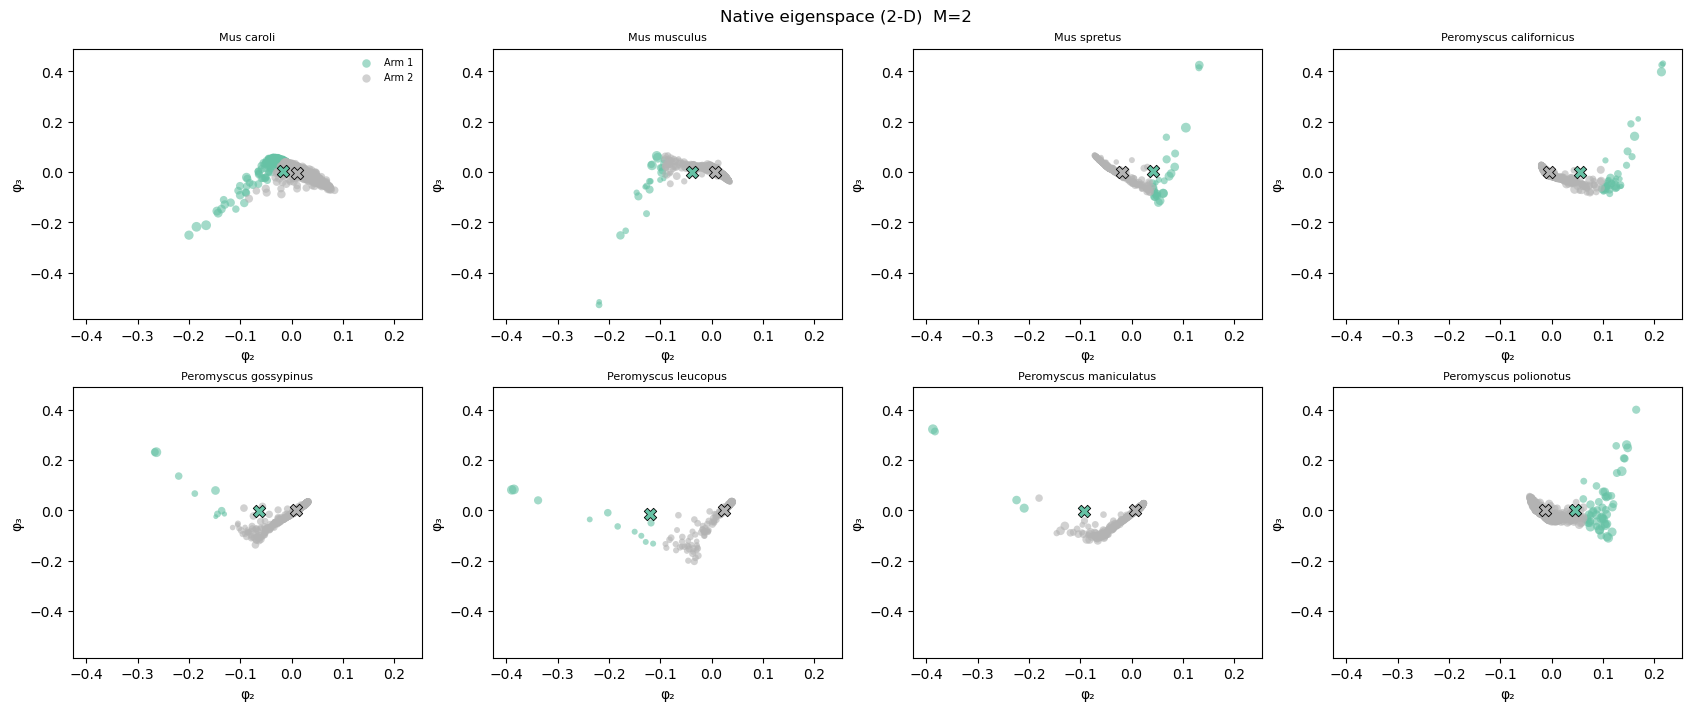

In [48]:
phi_natives = [arrs[sp].get("phi_macro_native") for sp in species_names]
lims_nat = grid_lims([p for p in phi_natives if p is not None])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 3.5*n_rows),
                          constrained_layout=True, squeeze=False)
for idx, sp in enumerate(species_names):
    ax   = axes.flat[idx]
    d    = arrs[sp]
    phi  = d.get("phi_macro_native")
    arms = d.get("arm_assignments_macro_aligned")
    occ  = d.get("macro_occupancy")
    if phi is None or phi.shape[1] < 2 or arms is None:
        ax.set_title(f"{sp.replace('_',' ')}\nno data"); continue
    occ   = occ / max(occ.sum(), 1e-12) if occ is not None else np.ones(len(phi))/len(phi)
    sizes = 6 + 44 * np.sqrt(occ / max(occ.max(), 1e-12))
    for arm in range(N_BASINS):
        mask = (arms == arm) & np.isfinite(phi[:,:2]).all(1) & (occ > 0)
        if not mask.any(): continue
        ax.scatter(phi[mask,0], phi[mask,1], s=sizes[mask],
                   color=arm_colors[arm], alpha=0.6, linewidths=0, label=f"Arm {arm+1}")
    chi_a = d.get("chi_macro_aligned"); pi_a = d.get("pi_macro")
    if chi_a is not None and pi_a is not None:
        ctrs = arm_centroid_in_space(phi[:,:2], chi_a, pi_a)
        for arm, ctr in enumerate(ctrs):
            ax.scatter(*ctr, s=80, marker="X", color=arm_colors[arm],
                       edgecolors="k", linewidths=0.6, zorder=5)
    ax.set_xlim(*lims_nat[0]); ax.set_ylim(*lims_nat[1])
    ax.set_xlabel("φ₂"); ax.set_ylabel("φ₃")
    ax.set_title(sp.replace("_"," "), fontsize=8)
    if idx == 0: ax.legend(fontsize=7, frameon=False)
for ax in axes.flat[n_sp:]: ax.remove()
fig.suptitle(f"Native eigenspace (2-D)  M={M_TEST}")
plt.show()


### 6c. Shared-Eigenspace Arm Scatter (2-D)

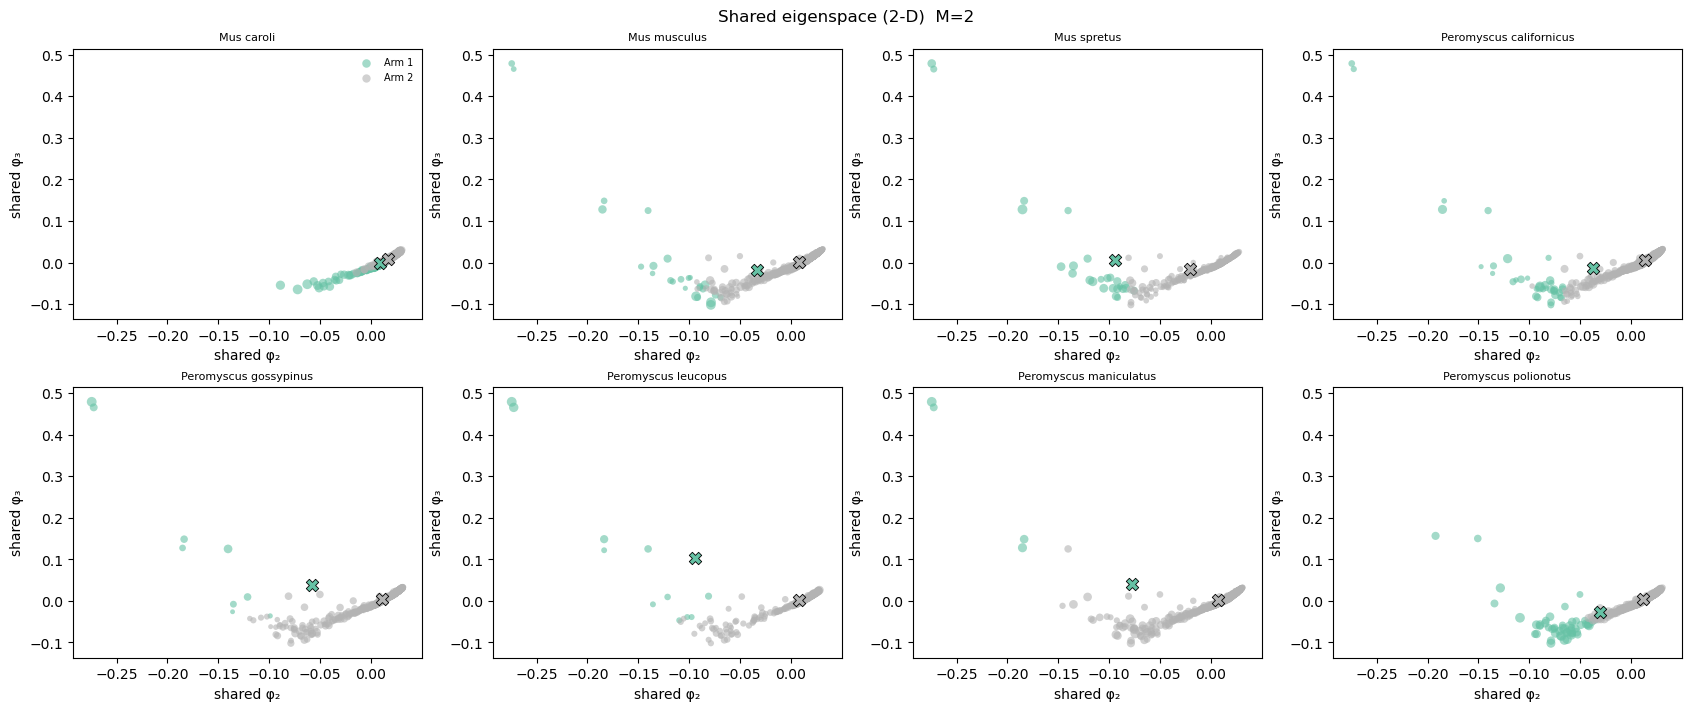

In [49]:
phi_shared = [arrs[sp].get("phi_macro_shared") for sp in species_names]
lims_sh = grid_lims([p for p in phi_shared if p is not None])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 3.5*n_rows),
                          constrained_layout=True, squeeze=False)
for idx, sp in enumerate(species_names):
    ax   = axes.flat[idx]
    d    = arrs[sp]
    phi  = d.get("phi_macro_shared")
    arms = d.get("arm_assignments_macro_aligned")
    occ  = d.get("macro_occupancy")
    if phi is None or phi.shape[1] < 2 or arms is None:
        ax.set_title(f"{sp.replace('_',' ')}\nno data"); continue
    occ   = occ / max(occ.sum(), 1e-12) if occ is not None else np.ones(len(phi))/len(phi)
    sizes = 6 + 44 * np.sqrt(occ / max(occ.max(), 1e-12))
    for arm in range(N_BASINS):
        mask = (arms == arm) & np.isfinite(phi[:,:2]).all(1) & (occ > 0)
        if not mask.any(): continue
        ax.scatter(phi[mask,0], phi[mask,1], s=sizes[mask],
                   color=arm_colors[arm], alpha=0.6, linewidths=0, label=f"Arm {arm+1}")
    chi_a = d.get("chi_macro_aligned"); pi_a = d.get("pi_macro")
    if chi_a is not None and pi_a is not None:
        ctrs = arm_centroid_in_space(phi[:,:2], chi_a, pi_a)
        for arm, ctr in enumerate(ctrs):
            ax.scatter(*ctr, s=80, marker="X", color=arm_colors[arm],
                       edgecolors="k", linewidths=0.6, zorder=5)
    ax.set_xlim(*lims_sh[0]); ax.set_ylim(*lims_sh[1])
    ax.set_xlabel("shared φ₂"); ax.set_ylabel("shared φ₃")
    ax.set_title(sp.replace("_"," "), fontsize=8)
    if idx == 0: ax.legend(fontsize=7, frameon=False)
for ax in axes.flat[n_sp:]: ax.remove()
fig.suptitle(f"Shared eigenspace (2-D)  M={M_TEST}")
plt.show()


### 6d. Global-Cluster N=1000 View

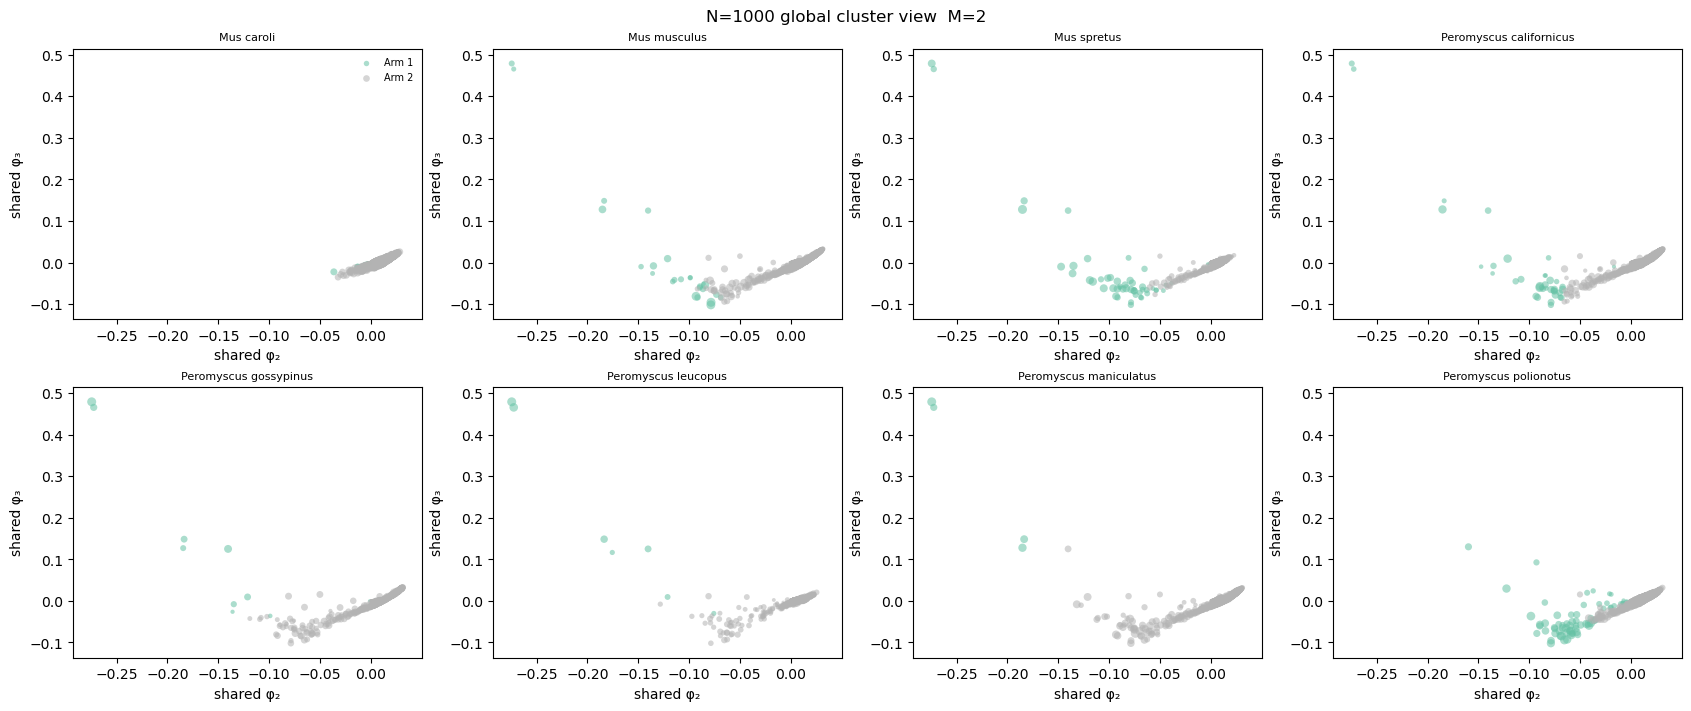

In [50]:
phi_gl = [arrs[sp].get("phi_global_shared") for sp in species_names]
lims_gl = grid_lims([p for p in phi_gl if p is not None])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 3.5*n_rows),
                          constrained_layout=True, squeeze=False)
for idx, sp in enumerate(species_names):
    ax   = axes.flat[idx]
    d    = arrs[sp]
    phi  = d.get("phi_global_shared")
    arms = d.get("arm_assignments_global_aligned")
    occ  = d.get("occupancy_global")
    if phi is None or phi.shape[1] < 2 or arms is None:
        ax.set_title(f"{sp.replace('_',' ')}\nno data"); continue
    occ   = occ / max(occ.sum(), 1e-12) if occ is not None else np.ones(len(phi))/len(phi)
    sizes = 4 + 38 * np.sqrt(occ / max(occ.max(), 1e-12))
    for arm in range(N_BASINS):
        mask = (arms == arm) & np.isfinite(phi[:,:2]).all(1) & (occ > 0)
        if not mask.any(): continue
        ax.scatter(phi[mask,0], phi[mask,1], s=sizes[mask],
                   color=arm_colors[arm], alpha=0.55, linewidths=0, label=f"Arm {arm+1}")
    ax.set_xlim(*lims_gl[0]); ax.set_ylim(*lims_gl[1])
    ax.set_xlabel("shared φ₂"); ax.set_ylabel("shared φ₃")
    ax.set_title(sp.replace("_"," "), fontsize=8)
    if idx == 0: ax.legend(fontsize=7, frameon=False)
for ax in axes.flat[n_sp:]: ax.remove()
fig.suptitle(f"N=1000 global cluster view  M={M_TEST}")
plt.show()


### 6e. Cosine-Similarity Matrix of Matched Arms

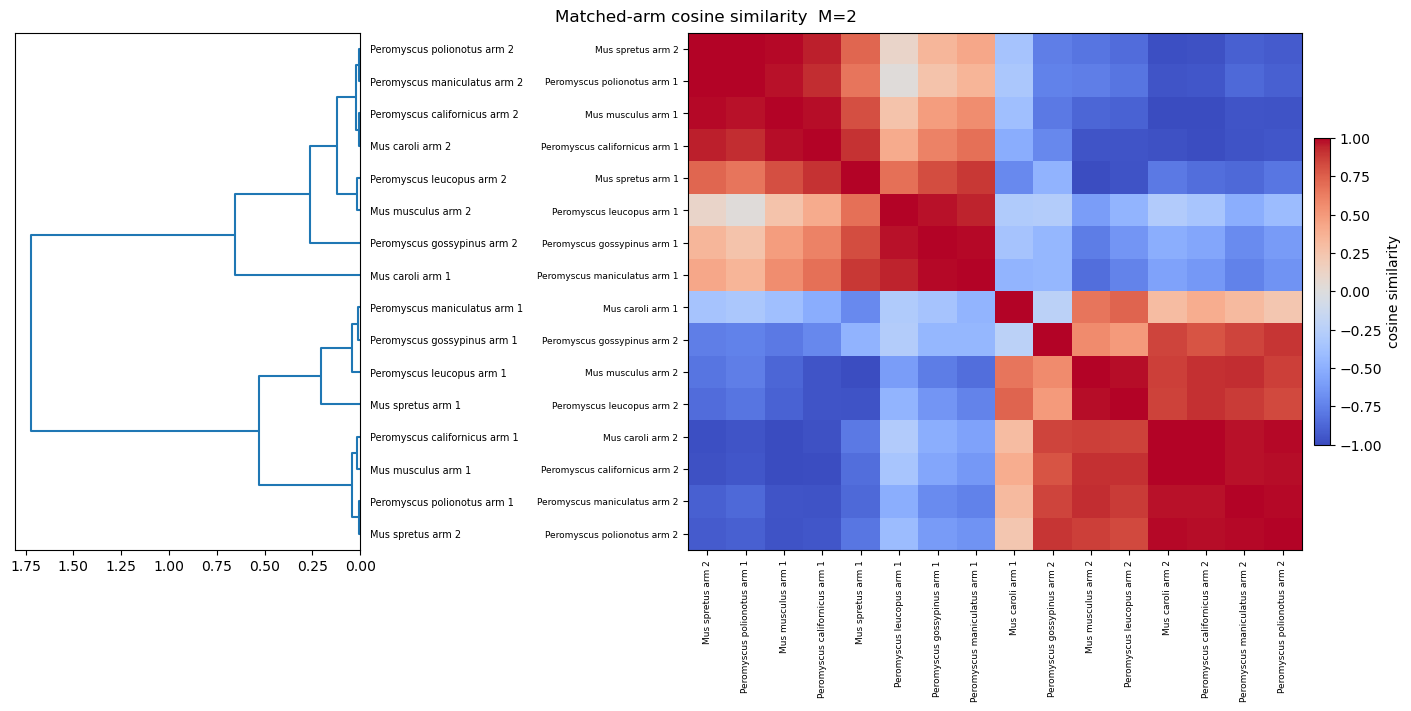

In [51]:
rows, vecs = [], []
for sp in species_names:
    d   = arrs[sp]
    phi = d.get("phi_macro_shared")
    chi = d.get("chi_macro_aligned")
    pi  = d.get("pi_macro")
    if phi is None or chi is None or pi is None or phi.shape[1] < 2:
        continue
    phi3 = phi[:, :3] if phi.shape[1] >= 3 else phi
    ctrs = arm_centroid_in_space(phi3, chi, pi)
    for arm, ctr in enumerate(ctrs):
        rows.append({"label": f"{sp.replace('_',' ')} arm {arm+1}", "arm": arm})
        vecs.append(ctr)

if len(vecs) >= 2:
    vecs  = np.asarray(vecs, float)
    unit  = normalise_rows(vecs)
    cosim = unit @ unit.T
    dist  = np.clip(1 - cosim, 0, 2)
    link  = linkage(squareform(dist, checks=False), method="average")
    order = leaves_list(link)
    ordered_sim    = cosim[np.ix_(order, order)]
    ordered_labels = [rows[i]["label"] for i in order]

    fig, axes = plt.subplots(1, 2,
                              figsize=(14, max(7, 0.28*len(ordered_labels))),
                              constrained_layout=True,
                              gridspec_kw={"width_ratios": [0.9, 1.6]})
    dendrogram(link, labels=[r["label"] for r in rows],
               orientation="left", ax=axes[0], leaf_font_size=7, color_threshold=0)
    im = axes[1].imshow(ordered_sim, cmap="coolwarm", vmin=-1, vmax=1,
                        aspect="auto", interpolation="nearest")
    axes[1].set_xticks(range(len(ordered_labels)))
    axes[1].set_xticklabels(ordered_labels, rotation=90, fontsize=6.5)
    axes[1].set_yticks(range(len(ordered_labels)))
    axes[1].set_yticklabels(ordered_labels, fontsize=6.5)
    fig.colorbar(im, ax=axes[1], label="cosine similarity", fraction=0.025, pad=0.02)
    fig.suptitle(f"Matched-arm cosine similarity  M={M_TEST}")
    plt.show()
else:
    print("Not enough vectors for cosine plot.")


### 6f. Per-Arm Cloud Plots (species coloured)

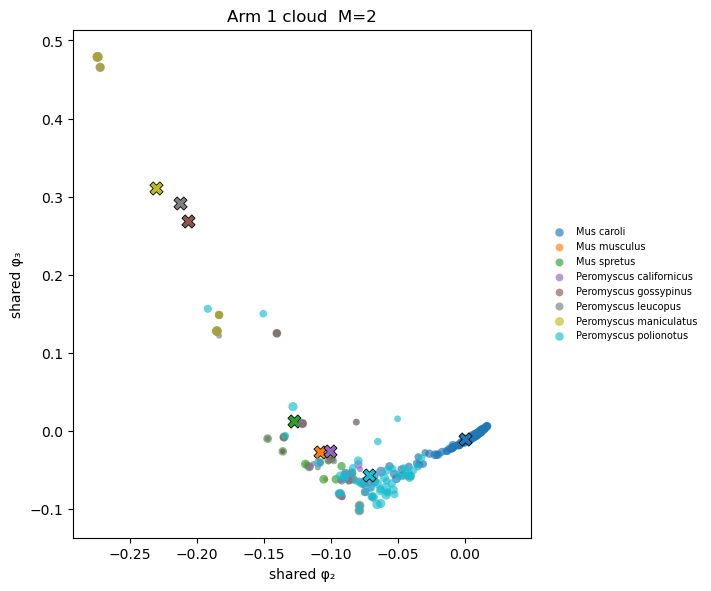

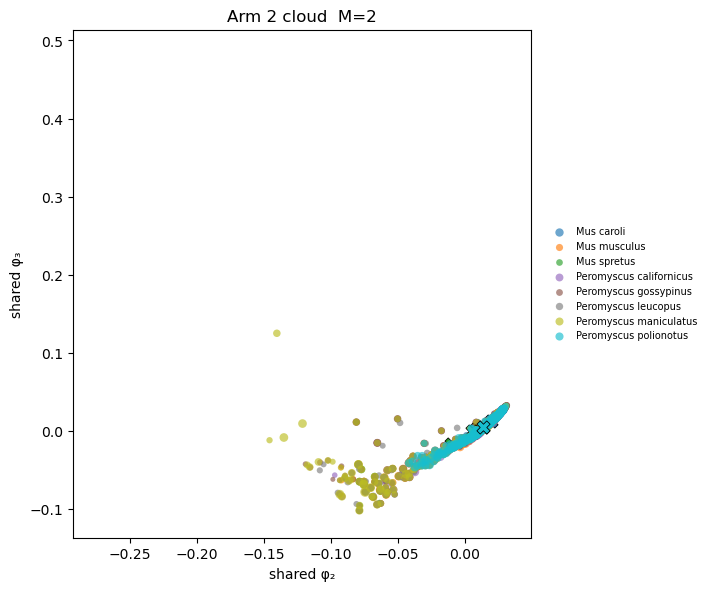

In [52]:
all_pts_sp = [arrs[sp].get("phi_macro_shared") for sp in species_names]
lims_arm   = grid_lims([p for p in all_pts_sp if p is not None])

for aligned_arm in range(N_BASINS):
    fig, ax = plt.subplots(figsize=(7, 5.8), constrained_layout=True)
    for sp in species_names:
        d    = arrs[sp]
        phi  = d.get("phi_macro_shared")
        arms = d.get("arm_assignments_macro_aligned")
        occ  = d.get("macro_occupancy")
        if phi is None or phi.shape[1] < 2 or arms is None:
            continue
        occ   = occ / max(occ.sum(), 1e-12) if occ is not None else np.ones(len(phi))/len(phi)
        mask  = (arms == aligned_arm) & (occ > 0) & np.isfinite(phi[:,:2]).all(1)
        if not mask.any(): continue
        sizes = 6 + 44 * np.sqrt(occ[mask] / max(occ.max(), 1e-12))
        col   = species_colors[sp]
        ctr   = np.average(phi[mask,:2], axis=0, weights=occ[mask])
        ax.scatter(phi[mask,0], phi[mask,1], s=sizes, color=col,
                   alpha=0.65, linewidths=0, label=sp.replace("_"," "))
        ax.scatter(*ctr, s=90, marker="X", color=col, edgecolors="k", linewidths=0.6)
    ax.set_xlim(*lims_arm[0]); ax.set_ylim(*lims_arm[1])
    ax.set_xlabel("shared φ₂"); ax.set_ylabel("shared φ₃")
    ax.set_title(f"Arm {aligned_arm+1} cloud  M={M_TEST}")
    ax.legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.show()


### 6g. UMAP Density and Log₂ Enrichment

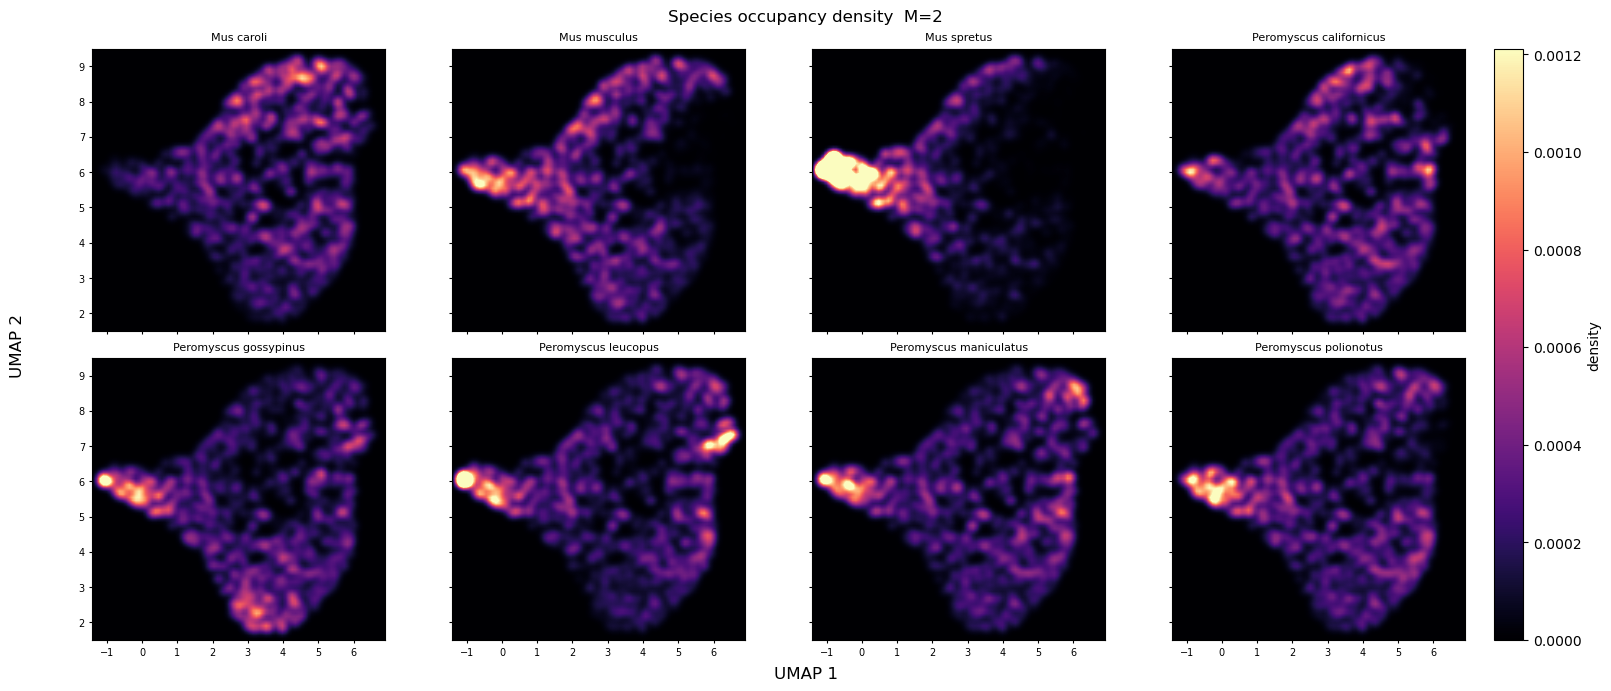

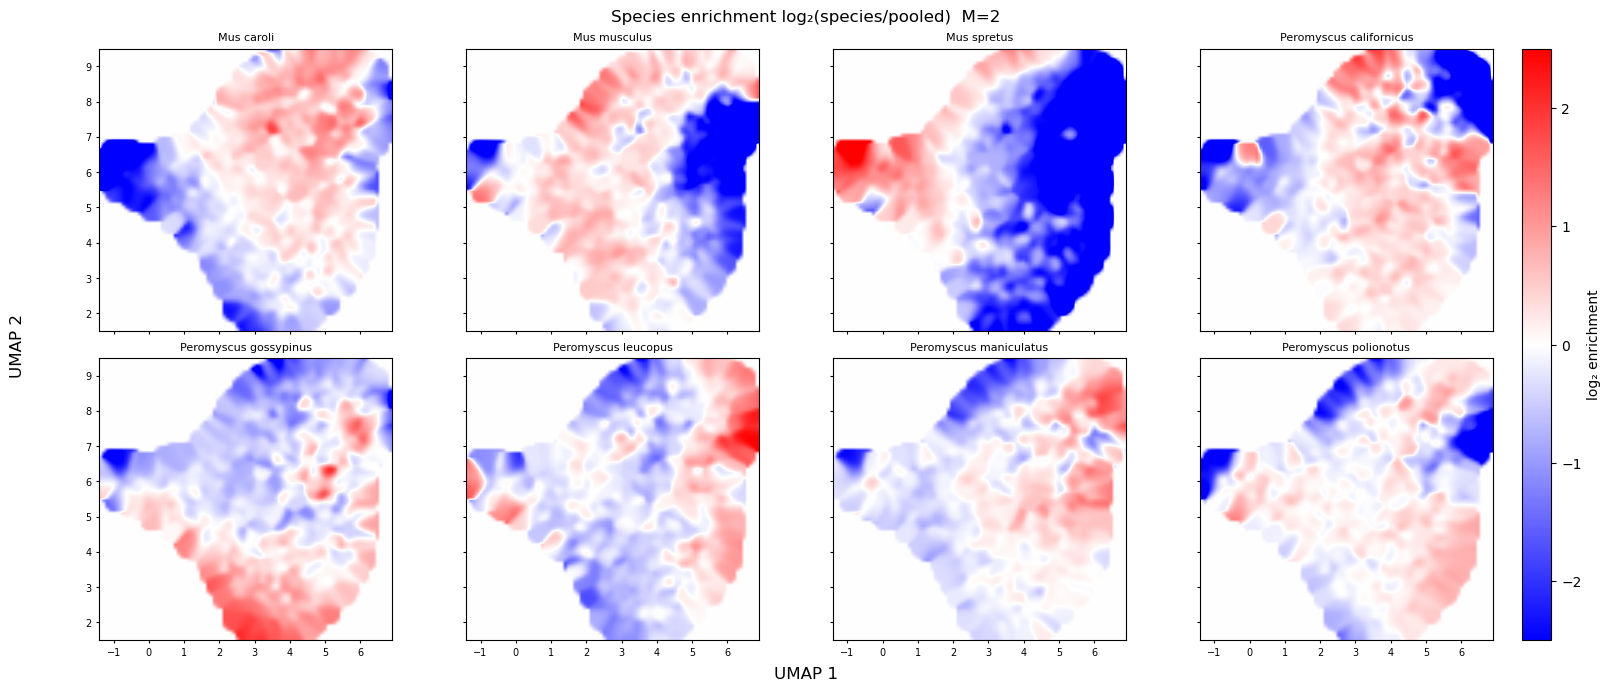

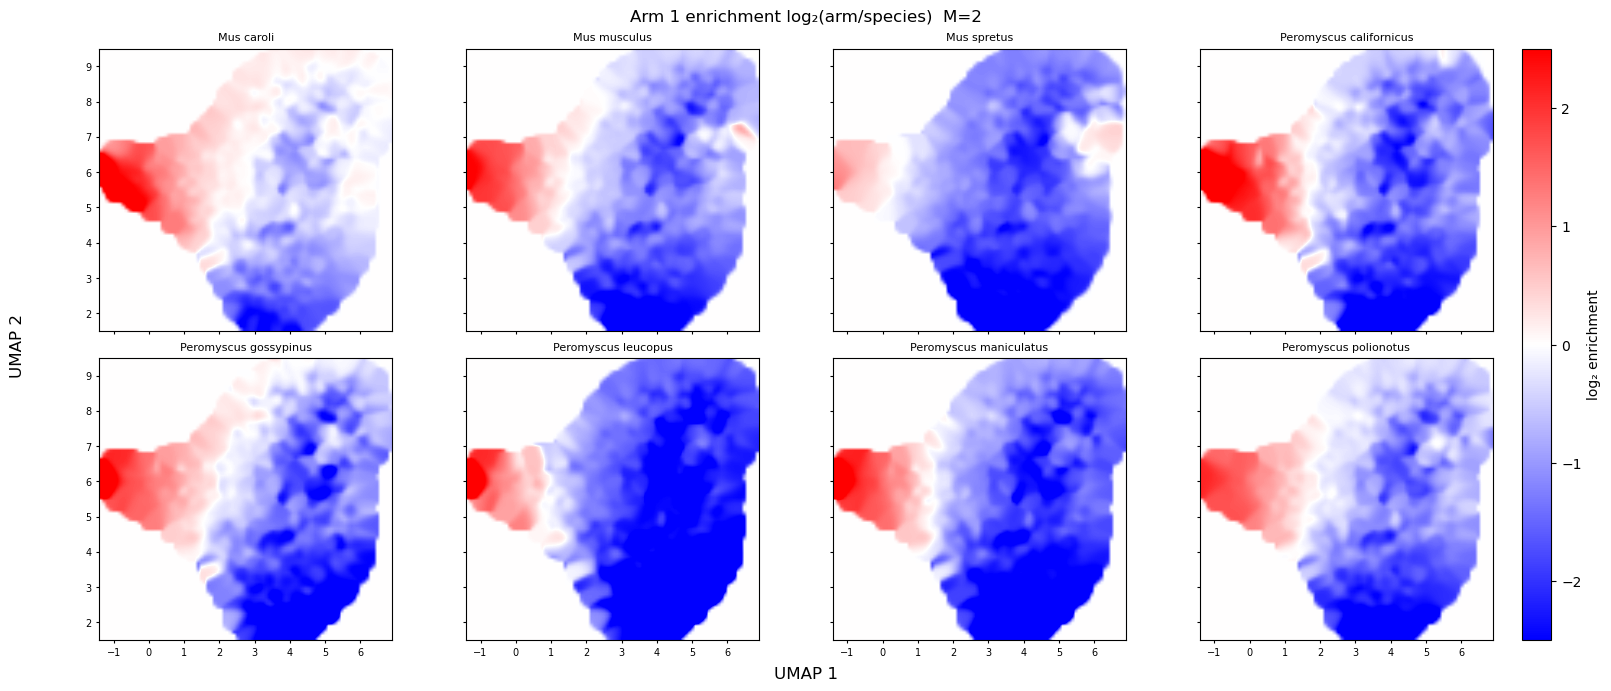

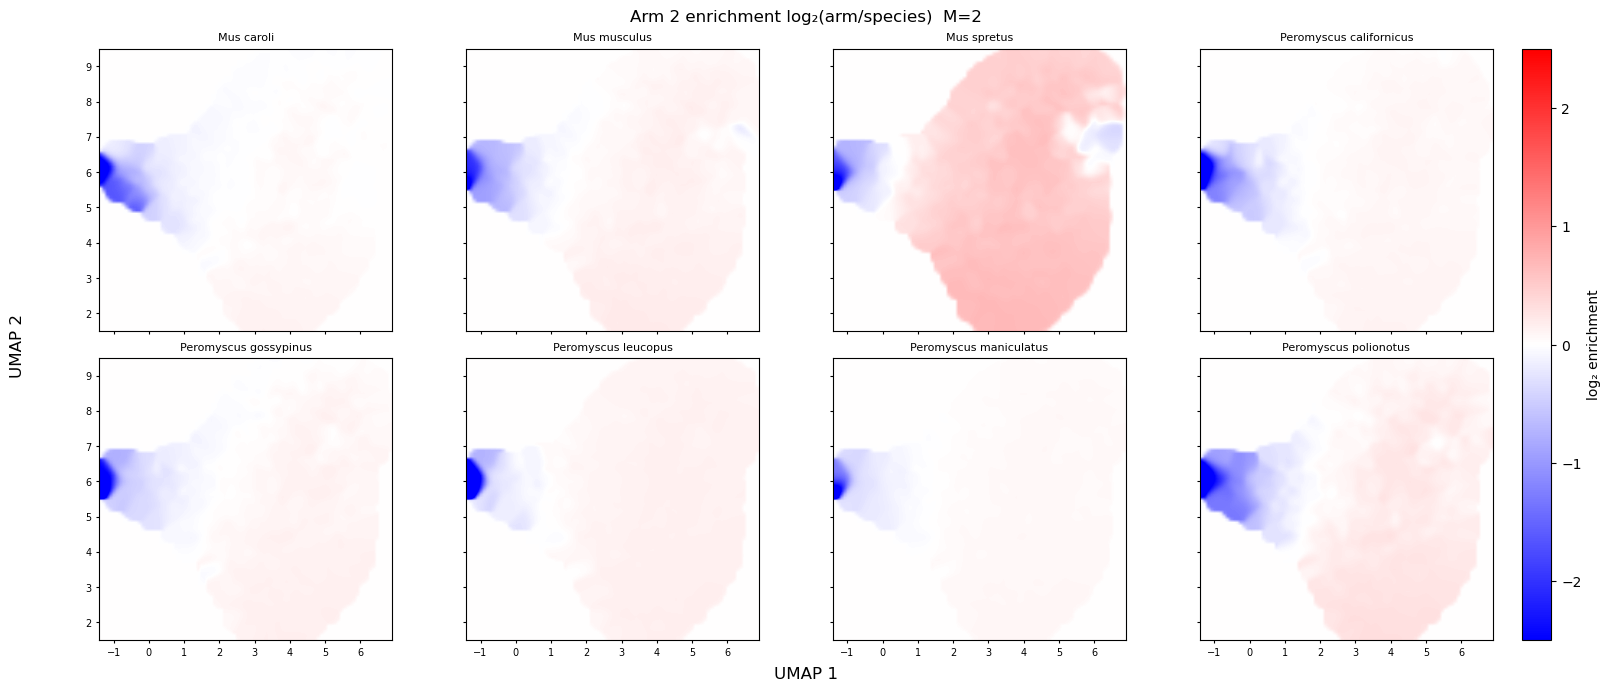

In [53]:
if cluster_layout_2d is None:
    print("Skipping UMAP panels: global_cluster_embedding.csv not found.")
else:
    x = cluster_layout_2d[:, 0].astype(float)
    y = cluster_layout_2d[:, 1].astype(float)
    x_rng = x.max() - x.min(); y_rng = y.max() - y.min()
    x_edges = np.linspace(x.min()-0.04*x_rng, x.max()+0.04*x_rng, DENSITY_BINS+1)
    y_edges = np.linspace(y.min()-0.04*y_rng, y.max()+0.04*y_rng, DENSITY_BINS+1)
    extent  = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

    def density_grid(weights, normalise=False):
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges],
                                  weights=np.asarray(weights, float))
        H = gaussian_filter(H.T, sigma=DENSITY_SIGMA, mode="constant")
        if normalise:
            H /= max(H.sum(), EPS)
        return H

    def log2_enrich(obs_w, ref_w):
        return np.log2((density_grid(obs_w, True)+EPS) / (density_grid(ref_w, True)+EPS))

    def umap_panels(panel_grids, title, cmap, cb_label, vmin=None, vmax=None):
        nc = min(4, n_sp); nr = int(np.ceil(n_sp/nc))
        fig_, axes_ = plt.subplots(nr, nc, figsize=(4.0*nc, 3.4*nr),
                                    sharex=True, sharey=True,
                                    constrained_layout=True, squeeze=False)
        im_ = None
        for ax_, sp in zip(axes_.flat, species_names):
            g = panel_grids.get(sp)
            if g is None: ax_.set_visible(False); continue
            im_ = ax_.imshow(g, origin="lower", extent=extent, cmap=cmap,
                              vmin=vmin, vmax=vmax, interpolation="bilinear", aspect="equal")
            ax_.set_title(sp.replace("_"," "), fontsize=8)
            ax_.tick_params(labelsize=7, length=2)
        for ax_ in axes_.flat[n_sp:]: ax_.remove()
        if im_ is not None:
            fig_.colorbar(im_, ax=axes_.flat[:n_sp], location="right",
                           fraction=0.025, pad=0.02, label=cb_label)
        fig_.supxlabel("UMAP 1"); fig_.supylabel("UMAP 2")
        fig_.suptitle(title); plt.show()

    # Occupancy density
    pooled_w = np.zeros(len(x))
    occ_grids = {}
    for sp in species_names:
        w = arrs[sp].get("occupancy_global", np.zeros(len(x))).astype(float)
        w /= max(w.sum(), EPS)
        occ_grids[sp] = density_grid(w)
        pooled_w += w
    pooled_w /= max(pooled_w.sum(), EPS)

    flat_vals = np.concatenate([g.ravel() for g in occ_grids.values()])
    vmax_occ  = np.percentile(flat_vals[flat_vals > 0], DENSITY_VMAX_P) if flat_vals.any() else 1.0
    umap_panels(occ_grids, f"Species occupancy density  M={M_TEST}", "magma", "density", 0, vmax_occ)

    # Species enrichment
    enrich_grids = {sp: log2_enrich(arrs[sp].get("occupancy_global", np.zeros(len(x))), pooled_w)
                    for sp in species_names}
    umap_panels(enrich_grids, f"Species enrichment log₂(species/pooled)  M={M_TEST}",
                "bwr", "log₂ enrichment", -ENRICH_VMAX, ENRICH_VMAX)

    # Per-arm enrichment
    for arm in range(N_BASINS):
        arm_enrich = {}
        for sp in species_names:
            chi = arrs[sp].get("chi_global_aligned")
            occ = arrs[sp].get("occupancy_global", np.zeros(len(x))).astype(float)
            if chi is None or chi.shape[1] <= arm:
                arm_enrich[sp] = np.zeros((DENSITY_BINS, DENSITY_BINS)); continue
            arm_enrich[sp] = log2_enrich(chi[:, arm] * occ, occ)
        umap_panels(arm_enrich, f"Arm {arm+1} enrichment log₂(arm/species)  M={M_TEST}",
                    "bwr", "log₂ enrichment", -ENRICH_VMAX, ENRICH_VMAX)


## 7. M Sweep — 3-D G-PCCA Plots

Runs G-PCCA at each value in `M_SWEEP`, aligns arms within each M to the first
species, and renders a 3-D scatter per M (shared eigenspace φ₂, φ₃, φ₄,
all 1 000 clusters, coloured by soft-argmax basin assignment).

Transfer matrices are built once and reused across M values.

In [54]:
# ── USER: set which M values to compare ──────────────────────────────────────
M_SWEEP = [3, 4]   # ← edit freely

# ─────────────────────────────────────────────────────────────────────────────
print("Building transfer matrices (cached across M values)…")
T_cache  = {}
pi_cache = {}
for species in ALL_SPECIES:
    print(f"  {species}…", end="", flush=True)
    T_cache[species]  = build_T(species)
    pi_cache[species] = stationary_dist(T_cache[species])
    print(" done")
print("\n✓ T matrices cached.")


Building transfer matrices (cached across M values)…
  Mus_caroli… done
  Mus_musculus… done
  Mus_spretus… done
  Peromyscus_californicus… done
  Peromyscus_gossypinus… done
  Peromyscus_leucopus… done
  Peromyscus_maniculatus… done
  Peromyscus_polionotus… done

✓ T matrices cached.


In [55]:
sweep_results = {}   # M_val -> {species: chi_global (1000, M_val) aligned}

for M_val in M_SWEEP:
    print(f"\n─── M = {M_val} ───")
    raw = {}
    for species in ALL_SPECIES:
        print(f"  {species}…", end="", flush=True)
        chi_g = run_gpcca(T_cache[species], pi_cache[species], M_val)
        raw[species] = chi_g
        print(" done")

    # Align every species to the first species as reference
    ref   = raw[ALL_SPECIES[0]]
    aligned_m = {ALL_SPECIES[0]: ref}
    for species in ALL_SPECIES[1:]:
        chi_aligned, col = hungarian_align(ref, raw[species])
        aligned_m[species] = chi_aligned
        print(f"    {species}: arm order → {col}")
    sweep_results[M_val] = aligned_m

print("\n✓ Sweep done.")



─── M = 3 ───
  Mus_caroli… done
  Mus_musculus… done
  Mus_spretus… done
  Peromyscus_californicus… done
  Peromyscus_gossypinus… done
  Peromyscus_leucopus… done
  Peromyscus_maniculatus… done
  Peromyscus_polionotus… done
    Mus_musculus: arm order → [2 0 1]
    Mus_spretus: arm order → [0 1 2]
    Peromyscus_californicus: arm order → [0 1 2]
    Peromyscus_gossypinus: arm order → [0 1 2]
    Peromyscus_leucopus: arm order → [0 1 2]
    Peromyscus_maniculatus: arm order → [0 1 2]
    Peromyscus_polionotus: arm order → [0 1 2]

─── M = 4 ───
  Mus_caroli… done
  Mus_musculus… done
  Mus_spretus… done
  Peromyscus_californicus… done
  Peromyscus_gossypinus… done
  Peromyscus_leucopus… done
  Peromyscus_maniculatus… done
  Peromyscus_polionotus… done
    Mus_musculus: arm order → [1 2 0 3]
    Mus_spretus: arm order → [0 3 1 2]
    Peromyscus_californicus: arm order → [0 1 2 3]
    Peromyscus_gossypinus: arm order → [0 1 2 3]
    Peromyscus_leucopus: arm order → [0 1 2 3]
    Peromys

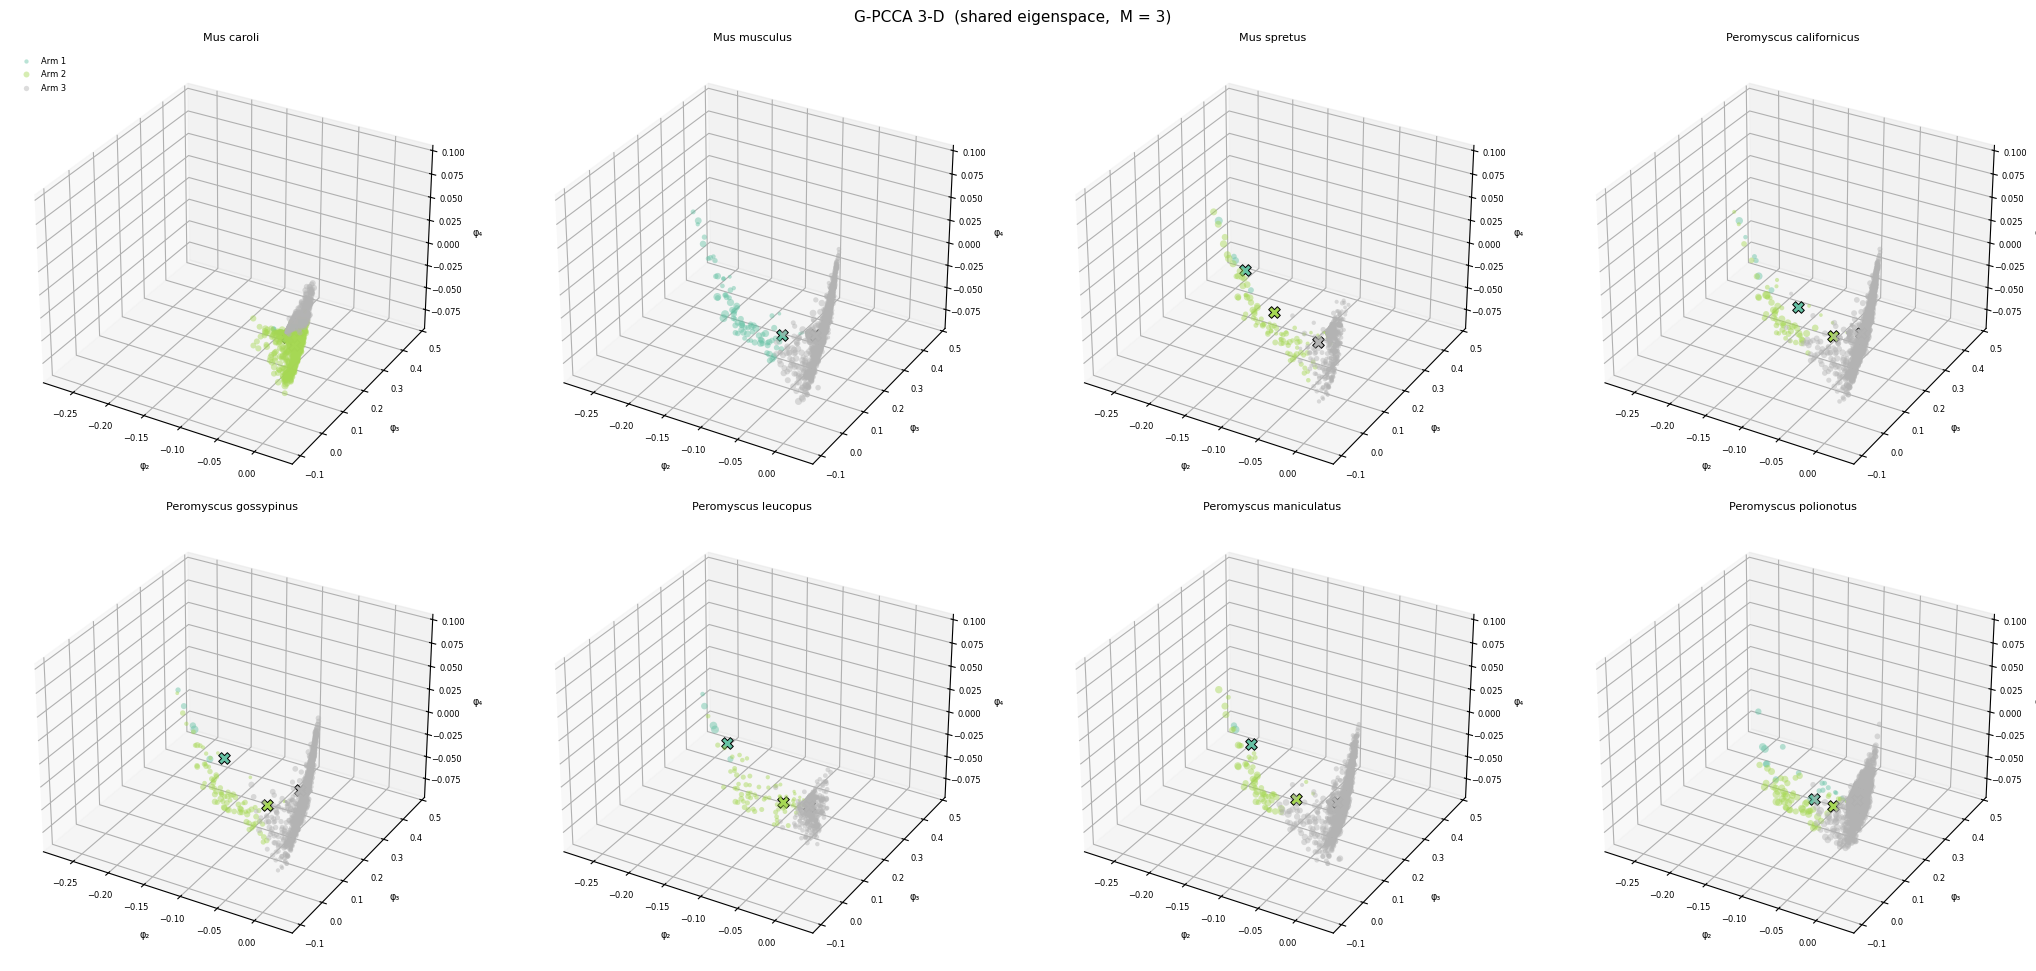

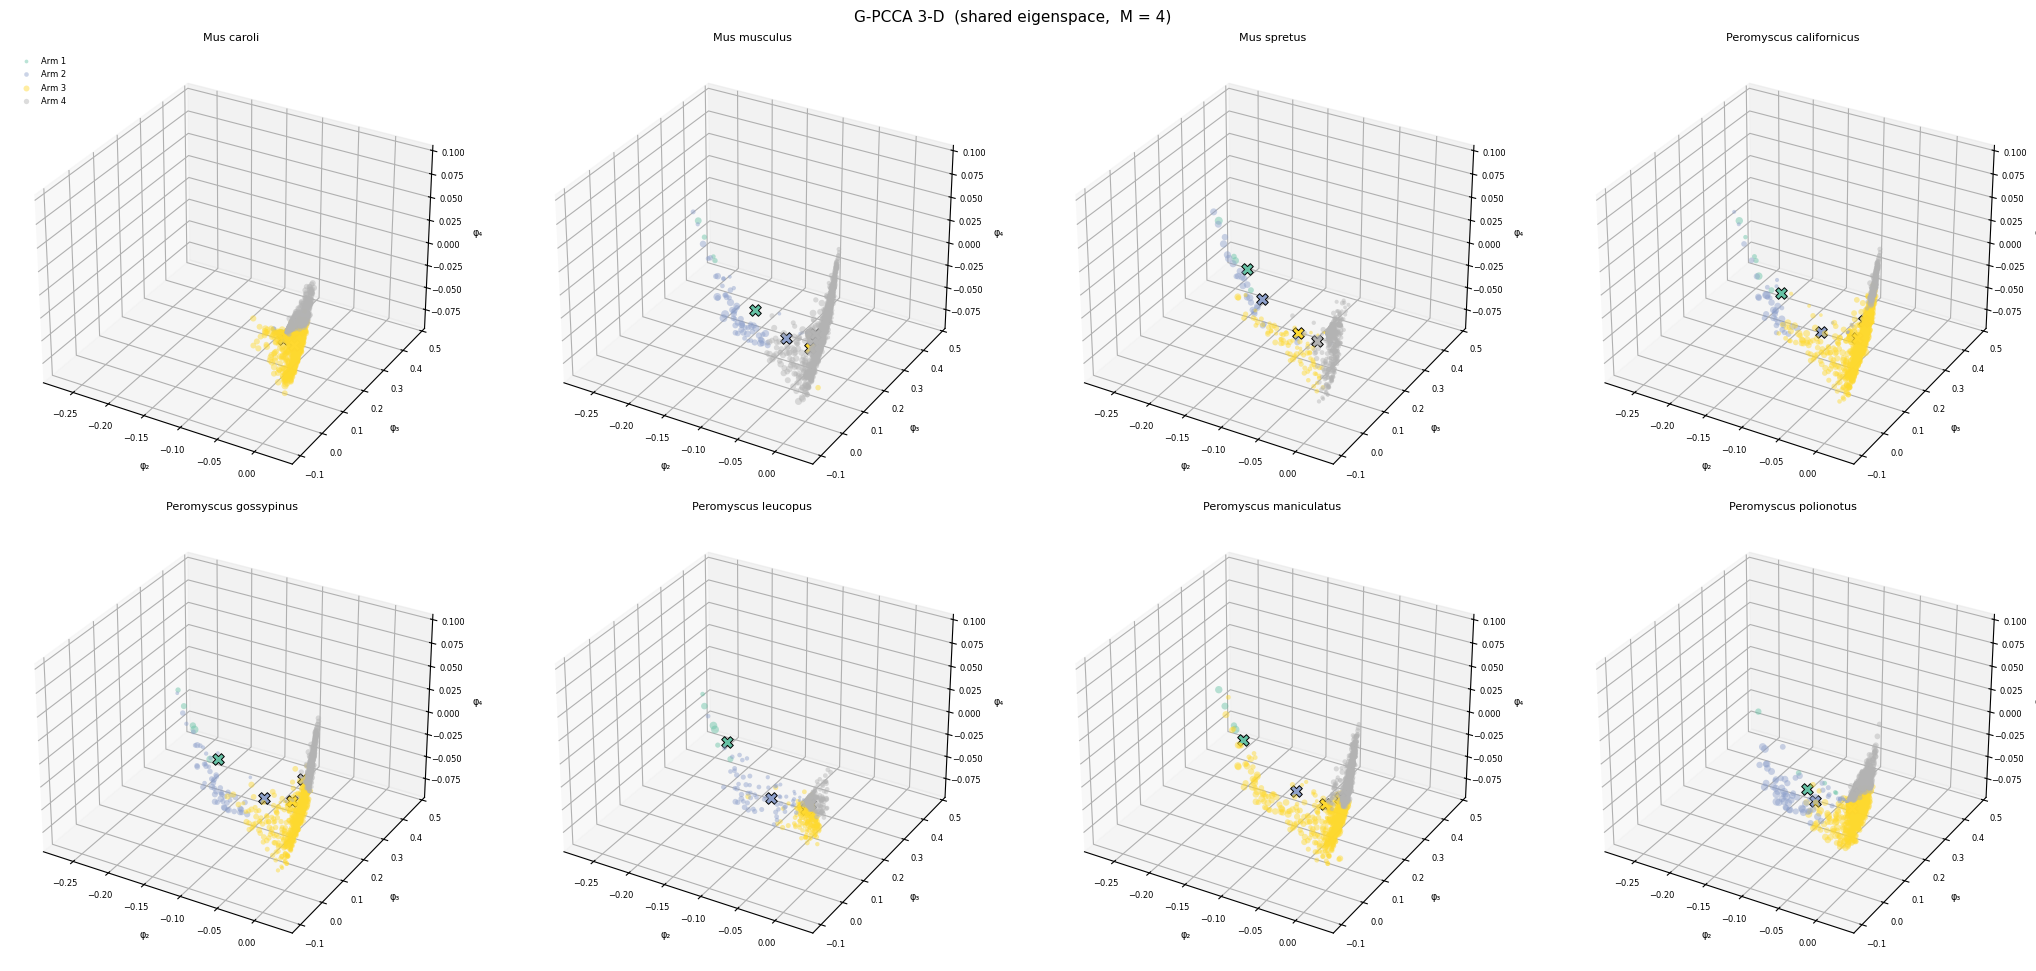

In [56]:
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

# Shared 3-D axis limits across all species (from phi_global_shared)
_pts = [arrs[sp]["phi_global_shared"][:, :3]
        for sp in species_names
        if "phi_global_shared" in arrs[sp] and arrs[sp]["phi_global_shared"].shape[1] >= 3]
_all = np.vstack(_pts); _all = _all[np.isfinite(_all).all(1)]
_lo, _hi = _all.min(0), _all.max(0)
_pad = 0.06 * np.maximum(_hi - _lo, 1e-12)
_lims3d = [(_lo[d]-_pad[d], _hi[d]+_pad[d]) for d in range(3)]

for M_val in M_SWEEP:
    aligned_m  = sweep_results[M_val]
    arm_clrs_m = [plt.get_cmap("Set2")(i / max(M_val-1, 1)) for i in range(M_val)]

    nc = min(4, n_sp); nr = int(np.ceil(n_sp / nc))
    fig = plt.figure(figsize=(5.2*nc, 4.8*nr), constrained_layout=True)

    for idx, sp in enumerate(species_names, 1):
        ax  = fig.add_subplot(nr, nc, idx, projection="3d")
        phi = arrs[sp].get("phi_global_shared")
        occ = arrs[sp].get("occupancy_global")
        chi = aligned_m[sp]
        if phi is None or phi.shape[1] < 3:
            ax.set_title(f"{sp.replace('_',' ')}\nno phi"); continue

        occ   = occ / max(occ.sum(), 1e-12) if occ is not None else np.ones(len(phi))/len(phi)
        arms  = chi.argmax(axis=1)
        sizes = 3 + 30 * np.sqrt(occ / max(occ.max(), 1e-12))

        for arm in range(M_val):
            mask = (arms == arm) & np.isfinite(phi[:, :3]).all(1) & (occ > 0)
            if not mask.any(): continue
            ax.scatter(*phi[mask, :3].T,
                       s=sizes[mask], color=arm_clrs_m[arm],
                       alpha=0.45, linewidths=0, label=f"Arm {arm+1}")

        # π-weighted centroids
        eta = pi_cache[sp]
        ctrs = np.zeros((M_val, 3))
        for arm in range(M_val):
            w = chi[:, arm] * eta
            ctrs[arm] = (phi[:, :3] * w[:, None]).sum(0) / max(w.sum(), 1e-12)
        for arm in range(M_val):
            ax.scatter(*ctrs[arm], s=70, marker="X",
                       color=arm_clrs_m[arm], edgecolors="k", linewidths=0.7, zorder=5)

        ax.set_xlim(*_lims3d[0]); ax.set_ylim(*_lims3d[1]); ax.set_zlim(*_lims3d[2])
        ax.set_xlabel("φ₂", fontsize=7, labelpad=1)
        ax.set_ylabel("φ₃", fontsize=7, labelpad=1)
        ax.set_zlabel("φ₄", fontsize=7, labelpad=1)
        ax.tick_params(labelsize=6, pad=1)
        ax.set_title(sp.replace("_", " "), fontsize=8)
        if idx == 1:
            ax.legend(fontsize=6, frameon=False, loc="upper left")

    fig.suptitle(f"G-PCCA 3-D  (shared eigenspace,  M = {M_val})", fontsize=11)
    plt.show()


## Summary

In [57]:
print(f"M_TEST = {M_TEST}")
print(f"Arrays saved to: {TEST_M_ROOT}")
print()
for sp in ALL_SPECIES:
    chi_g = arrs[sp].get("chi_global_aligned")
    chi_m = arrs[sp].get("chi_macro_aligned")
    arms_g = arrs[sp].get("arm_assignments_global_aligned")
    n_per_arm = [int((arms_g == a).sum()) for a in range(M_TEST)] if arms_g is not None else []
    print(f"  {sp:35s}  chi_global {chi_g.shape}  chi_macro {chi_m.shape}  clusters/arm {n_per_arm}")


M_TEST = 2
Arrays saved to: /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/test_M

  Mus_caroli                           chi_global (1000, 2)  chi_macro (625, 2)  clusters/arm [26, 974]
  Mus_musculus                         chi_global (1000, 2)  chi_macro (875, 2)  clusters/arm [29, 971]
  Mus_spretus                          chi_global (1000, 2)  chi_macro (425, 2)  clusters/arm [57, 943]
  Peromyscus_californicus              chi_global (1000, 2)  chi_macro (925, 2)  clusters/arm [37, 963]
  Peromyscus_gossypinus                chi_global (1000, 2)  chi_macro (975, 2)  clusters/arm [10, 990]
  Peromyscus_leucopus                  chi_global (1000, 2)  chi_macro (325, 2)  clusters/arm [7, 993]
  Peromyscus_maniculatus               chi_global (1000, 2)  chi_macro (925, 2)  clusters/arm [4, 996]
  Peromyscus_polionotus                chi_global (1000, 2)  chi_macro (675, 2)  clusters/arm [68, 932]
